# Handling Outliers

Outliers are those data points that are significantly different from the rest of the dataset. They are often abnormal observations that skew the data distribution, and arise due to inconsistent data entry, or erroneous observations

As outliers are very different values—abnormally low or abnormally high—their presence can often skew the results of statistical analyses on the dataset. This could lead to less effective and less useful models. that is the reason we need to handle the outliers.

### 5 number Summary
- Minimum, Maximum, Median, Q1, Q3, IQR

In [1]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# let's calculate the 5 number summary before deep dive into handling outliers
lst_marks=[45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74]
minimum,Q1,median,Q3,maximum= np.quantile(lst_marks,[0,0.25,0.50,0.75,1.0])
print(f'Minimum: {minimum}')
print(f'Q1: {Q1}')
print(f'Median: {median}')
print(f'Q3: {Q3}')
print(f'Maximum: {maximum}')

Minimum: 32.0
Q1: 54.0
Median: 67.0
Q3: 89.0
Maximum: 99.0


## Handling outliers 


### 1. Visualzining and Removing Outliers Using Box Plot

In [18]:
from sklearn.datasets import load_diabetes

# read the dataset
diabetes = load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [19]:
# creating dataframe
column_name = diabetes.feature_names
df = pd.DataFrame(diabetes.data, columns=column_name)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


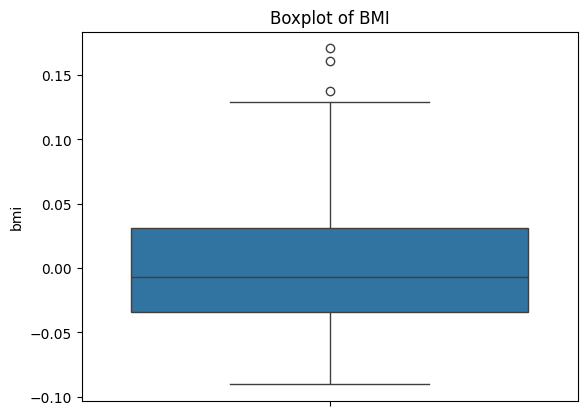

In [8]:
# bmi 
# let's plot the boxplot for bmi
sns.boxplot(df['bmi'])
plt.title('Boxplot of BMI')
plt.show()

<Axes: ylabel='bmi'>

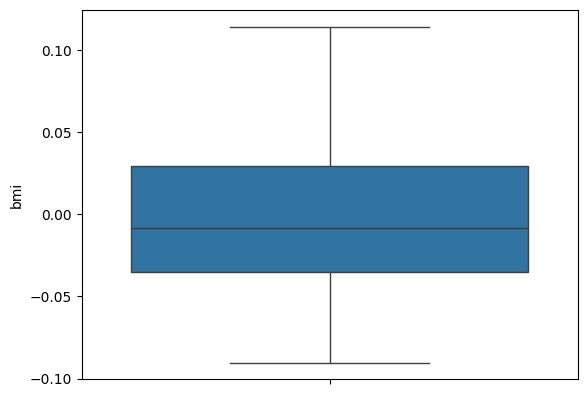

In [9]:
# From this graph, if we take 0.12 as threshold value and filter the data

removed_outlieres = df[df['bmi'] <= 0.12]
sns.boxplot(removed_outlieres['bmi'])


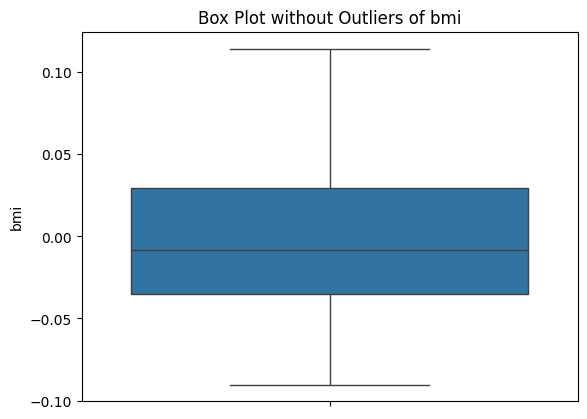

In [10]:
# we can even create a function for this
def removal_box_plot(df, column, threshold):
    removed_outliers = df[df[column] <= threshold]

    sns.boxplot(removed_outliers[column])
    plt.title(f'Box Plot without Outliers of {column}')
    plt.show()
    return removed_outliers


threshold_value = 0.12

no_outliers = removal_box_plot(df, 'bmi', threshold_value)

### 2. Z-score method for Outlier Detection


In [20]:
from scipy import stats

z = np.abs(stats.zscore(df['age']))
z[:10]

array([0.80050009, 0.03956713, 1.79330681, 1.87244107, 0.11317236,
       1.94881082, 0.9560041 , 1.33508832, 0.87686984, 1.49059233])

Now to define an outlier threshold value is chosen which is generally 3.0. As 99.7% of the data points lie between 
±3 standard deviation using Gaussian Distribution approach.

In [21]:
# let's remove rows where Z value is greater than 2
import numpy as np
threshold_z = 2
outliers_indices = np.where(z > threshold_z)[0]
no_outliers = df.drop(outliers_indices)
print('original dataframe shape: ', df.shape)
print('Dataframe shape after removing outliers: ', no_outliers.shape)

original dataframe shape:  (442, 10)
Dataframe shape after removing outliers:  (426, 10)


### 3. Interquartile Range (IQR) method

<Axes: ylabel='bmi'>

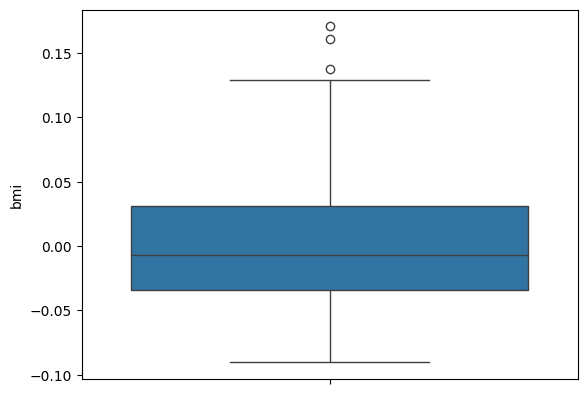

In [ ]:
# box plot of bmi to see outliers
sns.boxplot(df['bmi'])

In [24]:
# To remove the outliers from the 'bmi' column using (IQR)

Q1 = np.percentile(df['bmi'], 25, method='midpoint')
Q3 = np.percentile(df['bmi'], 75, method='midpoint')

IQR = Q3 - Q1 
print(IQR)

0.06520763046978838


<Axes: ylabel='bmi'>

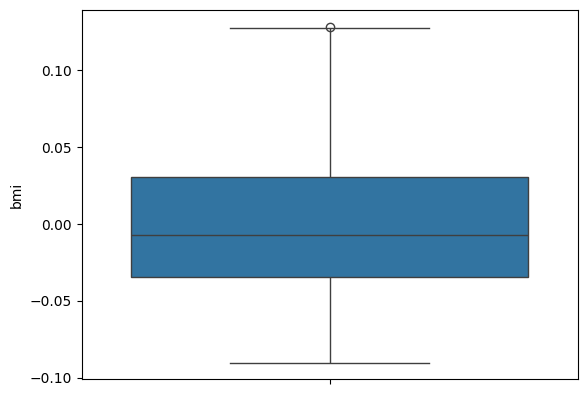

In [25]:
# calculate the upper bound and lower bound
upper = Q3 + 1.5 * IQR 
lower = Q1 - 1.5 * IQR 

upper_indices = np.where(df['bmi'] >= upper)[0]
lower_indices = np.where(df['bmi'] <= lower)[0]

df.drop(upper_indices, inplace = True)
df.drop(lower_indices, inplace=True)

sns.boxplot(df['bmi'])